In [ ]:
#imports
import carla
import numpy as np
import cv2
import time
from matplotlib import pyplot as plt
from IPython.display import display,clear_output

In [ ]:
def createRegionMask(image):
    """Create mask for region of interest - the area in front of the vehicle"""
    height, width = image.shape[:2]
    mask = np.zeros((height, width), dtype=np.uint8)
    
    # Define points for a wider and expanded trapezoid
    regionMaskVertices = np.array([
        [0, height], # Bottom left 
        [width * 0.35, height * 0.5], # Top left 
        [width * 0.65, height * 0.5], # Top right
        [width, height] # Bottom right
    ], np.int32)
    
    cv2.fillPoly(mask, [regionMaskVertices], 255)
    return mask

In [ ]:
def enhanceLaneLines(image):
    """Enhance lane line detection - focus on yellow and white lines"""
    # Convert to HSV for better color detection
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    
    # Define ranges for yellow lines
    yellowLowerRange = np.array([15, 40, 40])
    yellowUpperRange = np.array([35, 255, 255])
    yellowMask = cv2.inRange(hsv, yellowLowerRange, yellowUpperRange)
    
    # Define ranges for white lines
    whiteLower = np.array([0, 0, 200])
    whiteUpper = np.array([255, 30, 255])
    whiteMask = cv2.inRange(hsv, whiteLower, whiteUpper)
    
    # Combine masks
    combinedMask = cv2.bitwise_or(yellowMask, whiteMask)
    
    # Apply mask to original image
    maskedImage = cv2.bitwise_and(image, image, mask=combinedMask)
    
    return maskedImage, combinedMask

In [ ]:
def filterLinesByPosition(lines, imageWidth, imageCenter):
    """Filter lines based on their position relative to the center of the vehicle"""
    if lines is None:
        return [], []
    
    leftLines = []
    rightLines = []
    
    for line in lines:
        x1, y1, x2, y2 = line[0]
        
        # Calculate slope
        if x2 - x1 == 0:
            continue
        slope = (y2 - y1) / (x2 - x1)
        
        # Filter lines that are too horizontal or too steep
        if abs(slope) < 0.2 or abs(slope) > 3:
            continue
        
        # Calculate midpoint of the line
        midX = (x1 + x2) / 2
        
        # Calculate where the line intersects the bottom of the image
        intercept = y1 - slope * x1
        bottomX = (600 - intercept) / slope if slope != 0 else midX
        
        # Improved classification for left and right lines
        if slope < -0.2:  # Negative slope = left line
            if bottomX < imageCenter + 100:  # Some tolerance
                leftLines.append((slope, intercept))
        elif slope > 0.2:  # Positive slope = right line
            if bottomX > imageCenter - 100:  # Some tolerance
                rightLines.append((slope, intercept))
    
    return leftLines, rightLines

In [ ]:
def makeCoordinates(image, slope, intercept):
    """Create coordinates for a line based on slope and intercept - extended to full height"""
    y1 = image.shape[0]  # Bottom of image
    y2 = int(y1 * 0.5)   # Middle of image (instead of 0.6)
    
    if abs(slope) < 0.001:
        slope = 0.001 if slope >= 0 else -0.001
        
    x1 = int((y1 - intercept) / slope)
    x2 = int((y2 - intercept) / slope)
    
    # Ensure coordinates are within image bounds
    x1 = max(0, min(x1, image.shape[1] - 1))
    x2 = max(0, min(x2, image.shape[1] - 1))
    
    return np.array([x1, y1, x2, y2])


In [ ]:
def averageSlopeIntercept(image, lines):
    """Calculate average of slopes and intercepts for lane lines"""
    imageCenter = image.shape[1] // 2
    leftLines, rightLines = filterLinesByPosition(lines, image.shape[1], imageCenter)
    
    outputLines = []
    
    # Process left line
    if len(leftLines) > 0:
        avgSlope, avgIntercept = np.mean(leftLines, axis=0)
        coords = makeCoordinates(image, avgSlope, avgIntercept)
        outputLines.append(coords)
    
    # Process right line
    if len(rightLines) > 0:
        avgSlope, avgIntercept = np.mean(rightLines, axis=0)
        coords = makeCoordinates(image, avgSlope, avgIntercept)
        outputLines.append(coords)
    
    return outputLines

In [ ]:
def drawLines(image, lines):
    """Draw lane lines on the image"""
    lineImg = np.zeros_like(image)
    
    if lines is not None and len(lines) > 0:
        for line in lines:
            x1, y1, x2, y2 = line
            cv2.line(lineImg, (x1, y1), (x2, y2), (0, 255, 0), 8)
    
    return cv2.addWeighted(image, 0.8, lineImg, 1, 1)

In [ ]:
def drawLaneArea(image, lines):
    """Draw current lane area - improved"""
    if len(lines) == 2:  # There is a left and right line
        #laneImg = np.zeros_like(image)
        laneImg = np.zeros_like(image)
        
        leftLine = lines[0]
        rightLine = lines[1]
        
        # Ensure the left line is actually on the left and right on the right
        if leftLine[0] > rightLine[0]:  # If the "left" line is more to the right
            leftLine, rightLine = rightLine, leftLine
        
        # Create polygon from lane lines
        pts = np.array([
            [leftLine[0], leftLine[1]],   # Bottom left
            [leftLine[2], leftLine[3]],   # Top left
            [rightLine[2], rightLine[3]], # Top right
            [rightLine[0], rightLine[1]]  # Bottom right
        ], np.int32)
        
        cv2.fillPoly(laneImg, [pts], (0, 255, 255))
        return cv2.addWeighted(image, 0.7, laneImg, 0.3, 0)
    
    return image


In [ ]:
def processImage(image):
    """Process image for lane detection"""
    # Convert camera data to image
    img = np.frombuffer(image.raw_data, dtype=np.uint8)
    img = img.reshape((image.height, image.width, 4))[:, :, :3]
    
    # Enhance lane line detection
    enhancedImg, colorMask = enhanceLaneLines(img)
    
    # Create ROI mask
    regionInterestMask = createRegionMask(img)
    
    # Process image
    gray = cv2.cvtColor(enhancedImg, cv2.COLOR_BGR2GRAY)
    
    # Enhance contrast
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    
    # Apply ROI mask to enhanced image
    roiEnhanced = cv2.bitwise_and(enhanced, regionInterestMask)
    
    # Edge detection with adjusted parameters
    edges = cv2.Canny(roiEnhanced, 30, 100)
    
    # Line detection with improved parameters
    lines = cv2.HoughLinesP(
        edges, 
        rho=1, 
        theta=np.pi/180, 
        threshold=15,      # Even more sensitive
        minLineLength=25,  # Shorter lines
        maxLineGap=300     # Larger gaps
    )
    
    # Process lines
    averageLines = averageSlopeIntercept(img, lines)
    
    # Draw results
    laneImage = drawLaneArea(img, averageLines)
    laneImage = drawLines(laneImage, averageLines)
    
    # Display result
    clear_output(wait=True)
    plt.figure(figsize=(12, 8))
    
    # Display original image with lane detection
    plt.subplot(3, 1, 3)
    plt.imshow(cv2.cvtColor(laneImage, cv2.COLOR_BGR2RGB))
    plt.title("Lane Detection - Current Lane")
    plt.axis("off")
    

    # Display detected edges
    plt.subplot(3, 1, 2)
    plt.imshow(edges, cmap='gray')
    plt.title("Detected Edges")
    plt.axis("off")
    
    # Display original image
    plt.subplot(3, 1, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis("off")
    
    plt.tight_layout()
    plt.show()
    
    # Debug - print number of lines found
    if lines is not None:
        print(f"Found {len(lines)} lines, processed to {len(averageLines)} lane lines")
    else:
        print("No lines detected")

In [ ]:
client = carla.Client('localhost', 2000)
client.set_timeout(20.0)
client.load_world('Town03')
world=client.get_world()
blueprintLibrary=world.get_blueprint_library()

In [ ]:
vehicleBp=blueprintLibrary.filter('vehicle.mini.cooper_s_2021')[0]
spawnPoint=world.get_map().get_spawn_points()[0]
vehicle=world.spawn_actor(vehicleBp,spawnPoint)

In [ ]:
cameraBp = blueprintLibrary.filter('sensor.camera.rgb')[0]
cameraBp.set_attribute('image_size_x', '800')  # Higher resolution
cameraBp.set_attribute('image_size_y', '600')
cameraBp.set_attribute('fov', '90')  # More narrow viewing angle
cameraTransform = carla.Transform(
    carla.Location(x=2.0, z=1.4),  # Lower position and more forward
    carla.Rotation(pitch=-5.0)     # Slight downward tilt
)
camera=world.spawn_actor(cameraBp,cameraTransform,attach_to=vehicle)

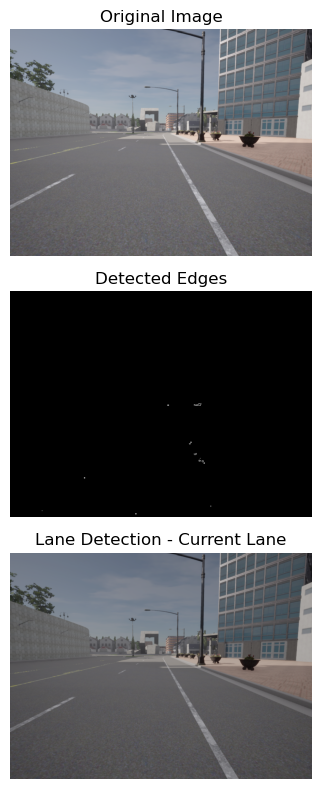

No lines detected


In [ ]:
camera.listen(lambda image:processImage(image))

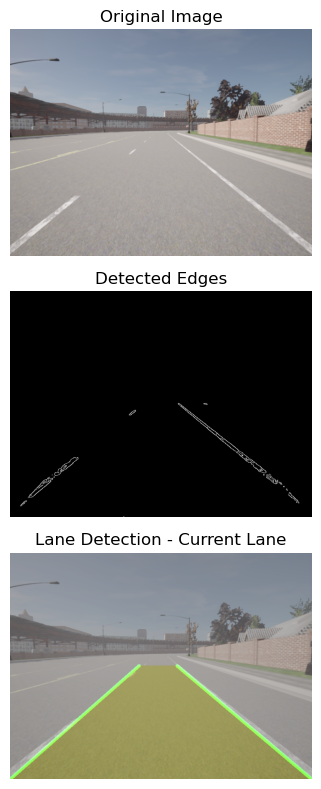

Found 28 lines, processed to 2 lane lines


In [ ]:
vehicle.set_autopilot(True)

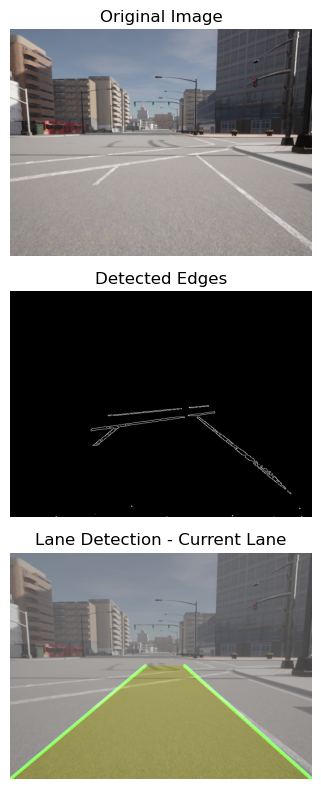

Found 30 lines, processed to 2 lane lines


In [ ]:
time.sleep(300)
camera.stop()

True

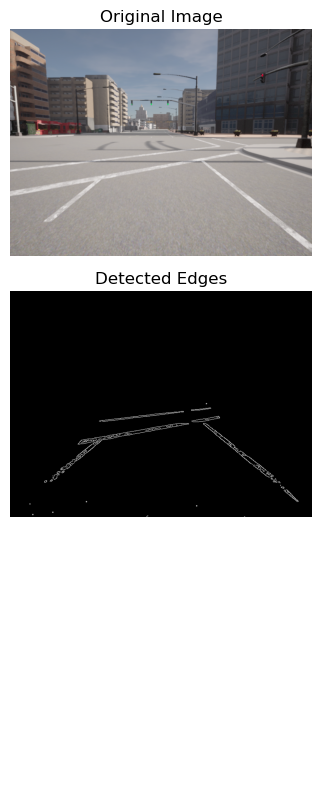

Found 42 lines, processed to 2 lane lines


In [ ]:

vehicle.destroy()
camera.destroy()